# Package

In [54]:
from ISLP import load_data
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Importation

In [37]:
carseats = load_data("carseats")

In [38]:
carseats.shape

(400, 11)

In [39]:
carseats.head(2)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes


*Les variables*
- Sales : Unit sales (in thousands) at each location

- CompPrice : Price charged by competitor at each location

- Income : Community income level (in thousands of dollars)

- Advertising : Local advertising budget for company at each location (in thousands of dollars)

- Population : Population size in region (in thousands)

- Price : Price company charges for car seats at each site

- ShelveLoc : A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site

- Age : Average age of the local population

- Education : Education level at each location

- Urban : A factor with levels No and Yes to indicate whether the store is in an urban or rural location

- US : A factor with levels No and Yes to indicate whether the store is in the US or not

# Feature engineering

In [40]:
# Ancienne logique
#carseats['Urban'] = carseats['Urban'].map({'Yes': 1, 'No': 0})
#carseats['USA'] = carseats['USA'].map({'Yes': 1, 'No': 0})

In [41]:
# Nouvelle logique : plus générale et s'applique dans pas mal de cas
carseats['Urban'] = carseats['Urban'].apply(lambda x:1 if x =="Yes" else 0)
carseats['US'] = carseats['US'].apply(lambda x:1 if x == "Yes" else 0)

# a) Fit Multiple regression model to predict Sales using Price, Urban, and US

## a1) Define the features and target

## Ancien logique : c'est très long comme code

cols = list(carseats.columns)

print(cols.index("Sales"), cols.index("Price"), cols.index("Urban"), cols.index("US") )

X_cols = [cols[5], cols[9], cols[10]]

X = MS(X_cols).fit_transform(carseats)

Y = carseats["Sales"]

model_1 = sm.OLS(Y, X)

result_1 = model_1.fit()

In [42]:
carseats['intercept'] = 1
carseats.head(2)
model_1 = sm.OLS(carseats['Sales'], carseats[['intercept', 'Price', 'US', 'Urban']]).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Tue, 30 Dec 2025   Prob (F-statistic):           2.39e-23
Time:                        10:34:28   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.0

# b) Interpretation 

**Significativité globale**

Vu le p-value du test de Fisher < 0.01, le modèle est donc significatif d'une manière globale

**Significativité de chaque variable**

Seule la variable "Urban" qui n'est donc pas significative.

**Price**

Le coefficient de "Price" sur "Sales" est négatif : -0.05. Ainsi, en moyenne, une augmentation 1$ du prix de l'automobile fait diminuer de 50 unités de sièges pour enfant vendus. Toute autre variable est fixe par ailleurs.

**US**

Le coefficient de "USA" sur "Sales" est égal à 1.2006. Le fait que le magasin soit aux Etats-Unis entraine une augmentation en moyenne de 1000 unités. Toute autre variable est fixe par ailleurs.

c) Model equation

Sales = -0.0545 * Price + 1.2006 * USA - 0.0219 * URBAN + Erreur

# d) Significativité

Déjà répondu

# e) Linear Regression with significant variables

In [43]:
model_2 = sm.OLS(carseats['Sales'], carseats[['intercept', 'Price', 'US']]).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Tue, 30 Dec 2025   Prob (F-statistic):           2.66e-24
Time:                        10:34:28   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.0

# f) Howe well do the models in (a) and (e) fit the model?

Les deux modèles ont un même R² et F-statistic. R² restent très faible avec une variance expliquée de 24% par le modèle. Celà nous dit que la relation peut être non linéaire. Voyons voir.

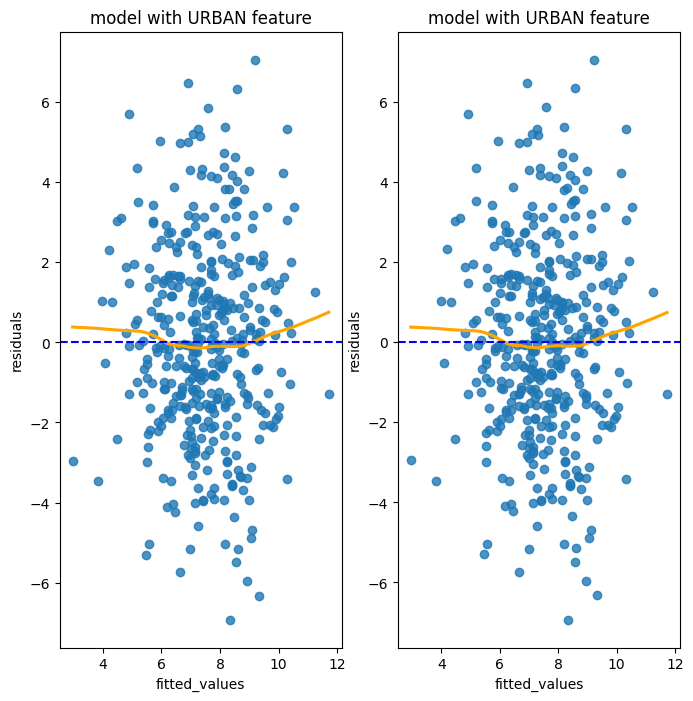

In [44]:
fig, axs = plt.subplots(1,2, figsize = (8,8))

sns.regplot(
    x = model_1.fittedvalues,
    y = model_1.resid,
    lowess=True,
    line_kws={"color" :"orange"},
    ax = axs[0]
)

axs[0].axhline(color = "b", linestyle = "--")
axs[0].set_xlabel("fitted_values")
axs[0].set_ylabel("residuals")
axs[0].set_title("model with URBAN feature")

sns.regplot(
    x = model_2.fittedvalues,
    y = model_2.resid,
    lowess=True,
    line_kws={"color" :"orange"},
    ax = axs[1]
)
axs[1].axhline(color = "b", linestyle = "--")
axs[1].set_xlabel("fitted_values")
axs[1].set_ylabel("residuals")
axs[1].set_title("model with URBAN feature")

plt.show()

On constate la non-linéarité. 

# g) Confidence intervals for the coefficient

In [45]:
model_2.conf_int(alpha=0.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US,0.69152,1.707766


# h) Outliers

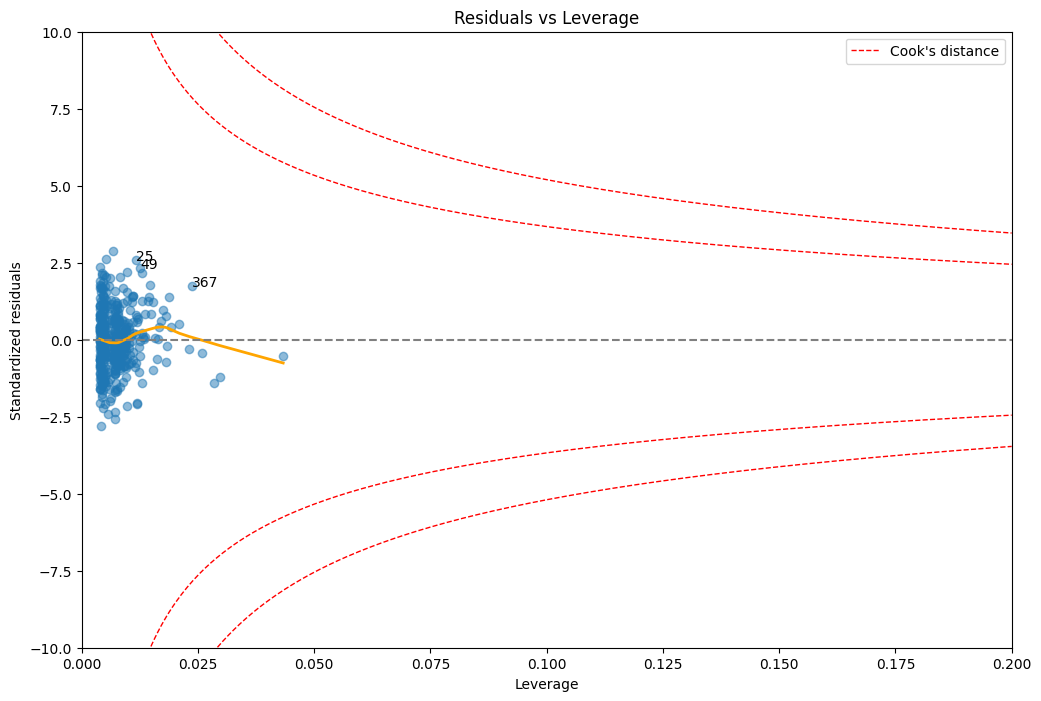

In [55]:
infl = model_2.get_influence()
r = infl.resid_studentized_internal
h = infl.hat_matrix_diag
D = infl.cooks_distance[0]
p = len(model_2.params)

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter
ax.scatter(h, r, alpha=0.5)

# LOWESS (tendance) en ORANGE
sns.regplot(
    x=h, y=r,
    scatter=False,
    lowess=True,
    ci=False,
    line_kws=dict(color='orange', lw=2),
    ax=ax
)

# Ligne y = 0
ax.axhline(0, color='gray', ls='--')

# Courbes de Cook (pointillés rouges)
hh = np.linspace(0.01, 0.20, 300)
for d in (0.5, 1):
    y = np.sqrt((d * p * (1 - hh)) / hh)
    ax.plot(hh,  y, 'r--', lw=1, label="Cook's distance" if d == 0.5 else None)
    ax.plot(hh, -y, 'r--', lw=1)

# Annoter les points les plus influents
for i in np.argsort(D)[-3:]:
    ax.annotate(i, (h[i], r[i]))

# 🔍 Dézoom contrôlé
ax.set_xlim(0, 0.20)
ax.set_ylim(-10, 10)

ax.set(
    title="Residuals vs Leverage",
    xlabel="Leverage",
    ylabel="Standardized residuals"
)

ax.legend(loc='upper right')
plt.show()

Leverage : c'est la contribution d'un point sur la prédiction y

Std_residual : l'écart entre la prédiction et la vraie valeur normalisé

Voici la règle d'intérprétation : 
- L élevé et SR faible : Combinaison de X très atypique (Outlier), çà dépend des données ; 
- L élevé et SR fort : influent ; 
- L faible et SR faible : point normal ; 
- L faible et SR élevé : Le modèle explique mal ce point. çà dépend de la spécification du modèle.

Nous avons donc un point qui a un L faible et SR très élevé. Nous pourrons encore améliorer ce modèle en ajoutant d'autres variables explicatives.